In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import anndata as ad
import logging
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import seaborn as sns
import sys
from matplotlib.lines import Line2D
from sccnasim.utils.gcna import load_cnas

In [3]:
utils_dir = "/groups/cgsd/xianjie/projects/cna-benchmark/HCC3N_600spot/simulator_evaluation/base/gen_data/sccnasim-cs_screadsim/analysis/sccnasim_cs_cna_signals/scripts"
sys.path.append(utils_dir)
from ubase import *
from urdr import *

In [4]:
feature_type = 'intergene'    # 'gene' or 'intergene'

In [5]:
cna_fn = '/groups/cgsd/xianjie/projects/cna-benchmark/HCC3N_600spot/simulator_evaluation/base/data/cna_profile.tsv'
in_dir = '/groups/cgsd/xianjie/projects/cna-benchmark/HCC3N_600spot/simulator_evaluation/base/gen_data/sccnasim-cs_screadsim/analysis/sccnasim_cs_cna_signals/%s/pp' % feature_type
out_dir = '/groups/cgsd/xianjie/projects/cna-benchmark/HCC3N_600spot/simulator_evaluation/base/gen_data/sccnasim-cs_screadsim/analysis/sccnasim_cs_cna_signals/%s' % feature_type 
chrom_anno_fn = '/groups/cgsd/xianjie/projects/cna-benchmark/HCC3N_600spot/simulator_evaluation/cs_benchmark/pseudobulk/data/chrom_arm_length.3col.tsv'

In [6]:
min_cells_per_gene = 3
min_gene_mean = 0.1

In [7]:
blue = '#0072B2'
orange = '#E69F00'
green = '#009E73'
red = '#D55E00'     # Vermillion

def_color = blue

In [8]:
cw_prefix = 'cw-'
gw_prefix = 'gw-'

dpi = 300

In [9]:
tool_labels = ['seed_N', 'scCNASim-cs_N', 'scCNASim-cs_T']

# Prepare Data

## Generate annotation of gene CNA type

In [10]:
os.makedirs(out_dir, exist_ok = True)

In [11]:
cna = load_cnas(cna_fn)
cna

,chrom,start,end,clone,cn_ale0,cn_ale1,region
0,1,123400001,248956422,tumor,1,2,1:123400001-248956422
1,4,50000001,190214555,tumor,0,1,4:50000001-190214555
2,8,1,45200000,tumor,0,1,8:1-45200000
3,8,45200001,145138636,tumor,1,2,8:45200001-145138636
4,13,17700001,114364328,tumor,2,0,13:17700001-114364328
5,17,1,25100000,tumor,2,0,17:1-25100000


In [12]:
adata = ad.read_h5ad(os.path.join(in_dir, "cs_normal.h5ad"))
adata

AnnData object with n_obs × n_vars = 600 × 21215
    obs: 'cell_type', 'cell'
    var: 'gene', 'chrom', 'start', 'end', 'cna_type', 'feature'

In [13]:
gene_anno = adata.var.copy()
gene_anno['gene'] = gene_anno['feature']
gene_anno['gene_cna_type'] = 'N.A.'
gene_anno

,gene,chrom,start,end,cna_type,feature,gene_cna_type
1_0_29554,1_0_29554,1,0,29554,neutral,1_0_29554,N.A.
1_31109_34554,1_31109_34554,1,31109,34554,neutral,1_31109_34554,N.A.
1_36081_65419,1_36081_65419,1,36081,65419,neutral,1_36081_65419,N.A.
1_71585_89295,1_71585_89295,1,71585,89295,neutral,1_71585_89295,N.A.
1_133723_139790,1_133723_139790,1,133723,139790,neutral,1_133723_139790,N.A.
...,...,...,...,...,...,...,...
9_137217009_137217452,9_137217009_137217452,9,137217009,137217452,neutral,9_137217009_137217452,N.A.
9_137219361_137220247,9_137219361_137220247,9,137219361,137220247,neutral,9_137219361_137220247,N.A.
9_137221581_137224635,9_137221581_137224635,9,137221581,137224635,neutral,9_137221581_137224635,N.A.
9_137226311_137227271,9_137226311_137227271,9,137226311,137227271,neutral,9_137226311_137227271,N.A.


In [14]:
def is_cna_feature(x, df):
    chrom, start, end = x["chrom"], x["start"], x["end"]
    d = df[(df["chrom"] == chrom) & (df["start"] <= end) & (df["end"] >= start)]
    return(d.shape[0] > 0)

In [15]:
# Neutral genes
bool_is_cna = adata.var.apply(is_cna_feature, axis = 1, df = cna)
cna_genes = adata.var["feature"][bool_is_cna].to_numpy()
print(cna_genes.shape)

gene_anno.loc[~(gene_anno['gene'].isin(cna_genes)), 'gene_cna_type'] = 'Neutral'
gene_anno['gene_cna_type'].value_counts()

(3413,)


gene_cna_type
Neutral    17802
N.A.        3413
Name: count, dtype: int64

In [16]:
# Gain genes
df_cna = cna.loc[cna['cn_ale0'] + cna['cn_ale1'] > 2].copy()
bool_is_cna = adata.var.apply(is_cna_feature, axis = 1, df = df_cna)
cna_genes = adata.var["feature"][bool_is_cna].to_numpy()
print(cna_genes.shape)

assert np.all(gene_anno.loc[gene_anno['gene'].isin(cna_genes), 'gene_cna_type'] == 'N.A.')
gene_anno.loc[gene_anno['gene'].isin(cna_genes), 'gene_cna_type'] = 'Gain'
gene_anno['gene_cna_type'].value_counts()

(1610,)


gene_cna_type
Neutral    17802
N.A.        1803
Gain        1610
Name: count, dtype: int64

In [17]:
# Loss genes
df_cna = cna.loc[cna['cn_ale0'] + cna['cn_ale1'] < 2].copy()
bool_is_cna = adata.var.apply(is_cna_feature, axis = 1, df = df_cna)
cna_genes = adata.var["feature"][bool_is_cna].to_numpy()
print(cna_genes.shape)

# for `intergene`, gain and loss regions have 1 overlapping feature, but the feature's counts are masked with 0,
# hence will be filtered by QC steps.
#assert np.all(gene_anno.loc[gene_anno['gene'].isin(cna_genes), 'gene_cna_type'] == 'N.A.')
gene_anno.loc[gene_anno['gene'].isin(cna_genes), 'gene_cna_type'] = 'Loss'
gene_anno['gene_cna_type'].value_counts()

(1006,)


gene_cna_type
Neutral    17802
Gain        1609
Loss        1006
N.A.         798
Name: count, dtype: int64

In [18]:
gene_anno.loc[gene_anno['gene'].isin(cna_genes), 'gene_cna_type']

4_49062081_51843000    Loss
4_51916837_51918772    Loss
4_51919381_51993702    Loss
4_52017620_52020706    Loss
4_52038482_52044805    Loss
                       ... 
8_42796392_42836674    Loss
8_42843325_42849637    Loss
8_43085788_43093506    Loss
8_43123434_43140455    Loss
8_43202855_46822237    Loss
Name: gene_cna_type, Length: 1006, dtype: object

In [19]:
# LOH genes
df_cna = cna.loc[cna['cn_ale0'] + cna['cn_ale1'] == 2].copy()
bool_is_cna = adata.var.apply(is_cna_feature, axis = 1, df = df_cna)
cna_genes = adata.var["feature"][bool_is_cna].to_numpy()
print(cna_genes.shape)

assert np.all(gene_anno.loc[gene_anno['gene'].isin(cna_genes), 'gene_cna_type'] == 'N.A.')
gene_anno.loc[gene_anno['gene'].isin(cna_genes), 'gene_cna_type'] = 'LOH'
gene_anno['gene_cna_type'].value_counts()

(798,)


gene_cna_type
Neutral    17802
Gain        1609
Loss        1006
LOH          798
Name: count, dtype: int64

## Load adata files

In [20]:
seed_normal_fn = os.path.join(in_dir, "seed_normal.h5ad")
cs_normal_fn = os.path.join(in_dir, "cs_normal.h5ad")
cs_tumor_fn = os.path.join(in_dir, "cs_tumor.h5ad")

In [21]:
seed_normal = ad.read_h5ad(seed_normal_fn)
print(seed_normal)

cs_normal = ad.read_h5ad(cs_normal_fn)
print(cs_normal)

cs_tumor = ad.read_h5ad(cs_tumor_fn)
print(cs_tumor)

AnnData object with n_obs × n_vars = 600 × 21215
    obs: 'cell', 'cell_type'
    var: 'gene', 'chrom', 'start', 'end', 'cna_type', 'feature'
AnnData object with n_obs × n_vars = 600 × 21215
    obs: 'cell_type', 'cell'
    var: 'gene', 'chrom', 'start', 'end', 'cna_type', 'feature'
AnnData object with n_obs × n_vars = 600 × 21215
    obs: 'cell_type', 'cell'
    var: 'gene', 'chrom', 'start', 'end', 'cna_type', 'feature'


## Load chrom annotations

In [22]:
chrom_anno = pd.read_csv(chrom_anno_fn, sep = '\t')
chrom_anno

,chrom,q_arm_start,q_arm_end
0,1,123400000,248956422
1,2,93900000,242193529
2,3,90900000,198295559
3,4,50000000,190214555
4,5,48800000,181538259
5,6,59800000,170805979
6,7,60100000,159345973
7,8,45200000,145138636
8,9,43000000,138394717
9,10,39800000,133797422


# Get metrics

In [23]:
mv = get_gw_metrics_group(
    X_lst = [seed_normal.X, cs_normal.X, cs_tumor.X],
    X_names = tool_labels,
    id_lst = [seed_normal.var['feature'].to_numpy(), cs_normal.var['feature'].to_numpy(), 
             cs_tumor.var['feature'].to_numpy()],
    metrics = ["mean", "var", "cv", "zero_prop"]
)
mv = mv.rename(columns = dict(X_name = 'group'))
mv

,mean,var,cv,zero_prop,group,feature
0,0.576667,0.680789,1.430808,0.586667,seed_N,1_0_29554
1,0.000000,0.000000,0.000000,1.000000,seed_N,1_31109_34554
2,0.000000,0.000000,0.000000,1.000000,seed_N,1_36081_65419
3,0.001667,0.001664,24.474475,0.998333,seed_N,1_71585_89295
4,0.131667,0.130997,2.748876,0.876667,seed_N,1_133723_139790
...,...,...,...,...,...,...
63640,0.088333,0.093864,3.468364,0.918333,scCNASim-cs_T,9_137217009_137217452
63641,0.120000,0.128933,2.992274,0.891667,scCNASim-cs_T,9_137219361_137220247
63642,0.108333,0.123264,3.240827,0.903333,scCNASim-cs_T,9_137221581_137224635
63643,0.125000,0.129375,2.877499,0.885000,scCNASim-cs_T,9_137226311_137227271


In [24]:
tmp = mv[["group", "feature", "mean", "var", "cv", "zero_prop"]]

tmp.to_csv(
    os.path.join(out_dir, gw_prefix + "metric_values.tsv"), 
    header = True, 
    index = False, 
    sep = "\t"
)

In [25]:
pairs = [
    ("scCNASim-cs_N", "seed_N"),
    ("scCNASim-cs_T", "scCNASim-cs_N")
]

selected_gvars = pd.DataFrame(data = dict(
    x = [p[1] for p in pairs],
    y = [p[0] for p in pairs],
))

In [26]:
st_log2fc = stat_log2fc(
    data = mv,
    metric = "mean", group = "group", gvars = selected_gvars
)
genes = mv.loc[mv['group'] == 'seed_N', 'feature'].to_numpy()
st_log2fc['gene'] = np.tile(genes, int(st_log2fc.shape[0] / len(genes)))
print(st_log2fc)


tmp = st_log2fc.copy()
tmp.to_csv(
    os.path.join(out_dir, gw_prefix + "log2fc-vs-mean.tsv"), 
    header = True, 
    index = False, 
    sep = "\t"
)

                   x              y    mean_x    mean_y    log2FC  \
0             seed_N  scCNASim-cs_N  0.576667  0.620000  0.104531   
1             seed_N  scCNASim-cs_N  0.000000  0.000000  0.000000   
2             seed_N  scCNASim-cs_N  0.000000  0.000000  0.000000   
3             seed_N  scCNASim-cs_N  0.001667  0.000000      -inf   
4             seed_N  scCNASim-cs_N  0.131667  0.140000  0.088537   
...              ...            ...       ...       ...       ...   
42425  scCNASim-cs_N  scCNASim-cs_T  0.105000  0.088333 -0.249359   
42426  scCNASim-cs_N  scCNASim-cs_T  0.111667  0.120000  0.103836   
42427  scCNASim-cs_N  scCNASim-cs_T  0.126667  0.108333 -0.225560   
42428  scCNASim-cs_N  scCNASim-cs_T  0.121667  0.125000  0.038994   
42429  scCNASim-cs_N  scCNASim-cs_T  0.116667  0.098333 -0.246640   

                        gene  
0                  1_0_29554  
1              1_31109_34554  
2              1_36081_65419  
3              1_71585_89295  
4            1_1

# Filter genes

In [27]:
mv_seed = mv.loc[mv['group'] == 'seed_N'].copy()
mv_seed['gene'] = mv_seed['feature']
mv_seed

,mean,var,cv,zero_prop,group,feature,gene
0,0.576667,0.680789,1.430808,0.586667,seed_N,1_0_29554,1_0_29554
1,0.000000,0.000000,0.000000,1.000000,seed_N,1_31109_34554,1_31109_34554
2,0.000000,0.000000,0.000000,1.000000,seed_N,1_36081_65419,1_36081_65419
3,0.001667,0.001664,24.474475,0.998333,seed_N,1_71585_89295,1_71585_89295
4,0.131667,0.130997,2.748876,0.876667,seed_N,1_133723_139790,1_133723_139790
...,...,...,...,...,...,...,...
21210,0.118333,0.124331,2.979764,0.891667,seed_N,9_137217009_137217452,9_137217009_137217452
21211,0.115000,0.118442,2.992640,0.893333,seed_N,9_137219361_137220247,9_137219361_137220247
21212,0.118333,0.120997,2.939548,0.890000,seed_N,9_137221581_137224635,9_137221581_137224635
21213,0.115000,0.118442,2.992640,0.893333,seed_N,9_137226311_137227271,9_137226311_137227271


In [28]:
n_cell = seed_normal.shape[0]
cutoff = 1 - min_cells_per_gene / n_cell
print(cutoff)
flag = mv_seed['zero_prop'] >= cutoff
n_gene = np.sum(flag)
print("%d genes will be excluded (min_cells_per_gene = %d)" % (n_gene, min_cells_per_gene))

0.995
6806 genes will be excluded (min_cells_per_gene = 3)


In [29]:
flag = mv_seed['mean'] < min_gene_mean
n_gene = np.sum(flag)
print("%d genes will be excluded (min_gene_mean = %f)" % (n_gene, min_gene_mean))

19411 genes will be excluded (min_gene_mean = 0.100000)


In [30]:
flag = mv_seed['zero_prop'] >= 1 - min_cells_per_gene / n_cell
flag |= mv_seed['mean'] < min_gene_mean
n_gene = np.sum(flag)
print("%d genes will be excluded (min_cells_per_gene = %d; min_gene_mean = %f)" % (n_gene, min_cells_per_gene, min_gene_mean))

19411 genes will be excluded (min_cells_per_gene = 3; min_gene_mean = 0.100000)


In [31]:
flag = mv_seed['zero_prop'] >= 1 - min_cells_per_gene / n_cell
flag |= mv_seed['mean'] < min_gene_mean
valid_genes = mv_seed.loc[~flag, 'feature'].to_numpy()
valid_genes.shape

(1804,)

In [32]:
st_log2fc_valid = st_log2fc.loc[st_log2fc['gene'].isin(valid_genes)].copy()
st_log2fc_valid = st_log2fc_valid.merge(gene_anno, on = 'gene', how = 'left')
st_log2fc_valid

,x,y,mean_x,mean_y,log2FC,gene,chrom,start,end,cna_type,feature,gene_cna_type
0,seed_N,scCNASim-cs_N,0.576667,0.620000,0.104531,1_0_29554,1,0,29554,neutral,1_0_29554,Neutral
1,seed_N,scCNASim-cs_N,0.131667,0.140000,0.088537,1_133723_139790,1,133723,139790,neutral,1_133723_139790,Neutral
2,seed_N,scCNASim-cs_N,0.625000,0.675000,0.111031,1_161525_358857,1,161525,358857,neutral,1_161525_358857,Neutral
3,seed_N,scCNASim-cs_N,0.288333,0.278333,-0.050924,1_451697_587629,1,451697,587629,neutral,1_451697_587629,Neutral
4,seed_N,scCNASim-cs_N,579.533333,588.150000,0.021292,1_594768_685679,1,594768,685679,neutral,1_594768_685679,Neutral
...,...,...,...,...,...,...,...,...,...,...,...,...
3603,scCNASim-cs_N,scCNASim-cs_T,0.105000,0.088333,-0.249359,9_137217009_137217452,9,137217009,137217452,neutral,9_137217009_137217452,Neutral
3604,scCNASim-cs_N,scCNASim-cs_T,0.111667,0.120000,0.103836,9_137219361_137220247,9,137219361,137220247,neutral,9_137219361_137220247,Neutral
3605,scCNASim-cs_N,scCNASim-cs_T,0.126667,0.108333,-0.225560,9_137221581_137224635,9,137221581,137224635,neutral,9_137221581_137224635,Neutral
3606,scCNASim-cs_N,scCNASim-cs_T,0.121667,0.125000,0.038994,9_137226311_137227271,9,137226311,137227271,neutral,9_137226311_137227271,Neutral


# Plot RDR signals

In [33]:
chr_info = {}
for i in range(chrom_anno.shape[0]):
    chr_info[str(chrom_anno['chrom'].iloc[i])] = (
        chrom_anno['q_arm_end'].iloc[i],
        chrom_anno['q_arm_start'].iloc[i]
    )
chr_info

{'1': (248956422, 123400000),
 '2': (242193529, 93900000),
 '3': (198295559, 90900000),
 '4': (190214555, 50000000),
 '5': (181538259, 48800000),
 '6': (170805979, 59800000),
 '7': (159345973, 60100000),
 '8': (145138636, 45200000),
 '9': (138394717, 43000000),
 '10': (133797422, 39800000),
 '11': (135086622, 53400000),
 '12': (133275309, 35500000),
 '13': (114364328, 17700000),
 '14': (107043718, 17200000),
 '15': (101991189, 19000000),
 '16': (90338345, 36800000),
 '17': (83257441, 25100000),
 '18': (80373285, 18500000),
 '19': (58617616, 26200000),
 '20': (64444167, 28100000),
 '21': (46709983, 12000000),
 '22': (50818468, 15000000)}

In [34]:
def plot_rdr(st_log2fc, out_fn, figsize = (10, 1), dpi = 300):
    chr_list = list(chr_info.keys())
    x_total = 0
    chr_bounds = {}
    arm_bounds = []
    gap = 1e7      # otherwise, points could overlap bound lines.
    fontsize = 7

    for chr_num in chr_list:
        len_chr, cen_pos = chr_info[chr_num]
        p_start = x_total
        q_start = x_total + cen_pos + gap
        chr_end = x_total + len_chr + gap*2
        chr_bounds[chr_num] = (p_start, q_start, chr_end)
        arm_bounds.append(q_start)
        x_total = chr_end

    color_dict = {
        "Gain": "#D14050",
        "Loss": "#0078BB",
        "LOH": "#40B5A8",
        "Neutral": '#B3B3B3'
    }

    df = pd.DataFrame(data = {
        'chr': st_log2fc['chrom'].astype(str),
        'x': (st_log2fc['start'] + st_log2fc['end']) / 2.0,
        'log2FC': st_log2fc['log2FC'],
        'cnv_state': st_log2fc['gene_cna_type']
    })
    for chr_num in chr_list:
        df.loc[df['chr'] == chr_num, 'x'] += chr_bounds[chr_num][0] + gap

    # Plot
    fig, ax = plt.subplots(1, 1, figsize = figsize, dpi = dpi)

    ax.axhline(0, color = 'black', lw = 1, ls = '--', alpha = 0.7)
    for chr_num in chr_list:    # Chromosome and arm borders
        ax.axvline(chr_bounds[chr_num][0], color = "#bbbbbb", lw = 1.0, zorder = 0)
    for pos in arm_bounds:
        ax.axvline(pos, color = "#e0e0e0", lw = 0.5, ls = '--', zorder = 0)

    # Neutral genes
    pointsize = 2
    neu = df[df.cnv_state == "Neutral"]
    sns.scatterplot(
        data = neu, x = "x", y = "log2FC", 
        color = color_dict["Neutral"], s = pointsize, alpha = 0.9, 
        ax = ax, zorder = 1
    )
    # CNA genes
    for state in ["Gain", "Loss", "LOH"]:
        sub = df[df.cnv_state == state]
        sns.scatterplot(
            data = sub, x = "x", y = "log2FC", color = color_dict[state], 
            s = pointsize, alpha = 0.9, 
            ax = ax, zorder = 2
        )
    # Median line.
    for chr_num in chr_list:
        sub = df.loc[(df.chr == chr_num) & (df.x < chr_bounds[chr_num][1])].sort_values("x")
        ax.hlines(sub.log2FC.median(), xmin = sub.x.min(), xmax = sub.x.max(), color = "#8B0000", lw = 1, zorder = 3)
        sub = df.loc[(df.chr == chr_num) & (df.x >= chr_bounds[chr_num][1])].sort_values("x")
        ax.hlines(sub.log2FC.median(), xmin = sub.x.min(), xmax = sub.x.max(), color = "#8B0000", lw = 1, zorder = 3)

    markersize = fontsize - 1.5
    legend_elements = [
        Line2D([0],[0], marker = 'o', color = 'w', markerfacecolor = color_dict["Gain"], 
               markersize = markersize, label = 'Gain'),
        Line2D([0],[0], marker = 'o', color = 'w', markerfacecolor = color_dict["Loss"], 
               markersize = markersize, label = 'Loss'),
        Line2D([0],[0], marker = 'o', color = 'w', markerfacecolor = color_dict["LOH"], 
               markersize = markersize, label = 'LOH'),
        Line2D([0],[0], marker = 'o', color = 'w', markerfacecolor = color_dict["Neutral"], 
               markersize = markersize, label = 'Neutral')
    ]
    fig.legend(
        handles = legend_elements, loc = "center left", bbox_to_anchor = (0.975, 0.5), 
        frameon = False, fontsize = fontsize, handletextpad = 0.1)

    for ax in [ax]:
        ax.spines['top'].set_visible(True)
        ax.spines['right'].set_visible(True)

    ax.set_xlabel(None)
    ax.set_ylabel(r"Log$_2$FC", fontsize = fontsize)
    ax.set_xticks([(v[0]+v[2])/2 for v in chr_bounds.values()])
    ax.set_xticklabels([str(c) for c in chr_list], fontsize = fontsize)
    ax.tick_params(axis = 'x', length = 0)
    ax.set_xlim(0, chr_bounds['22'][-1])
    ax.set_yticks([-2, -1, 0, 1, 2])
    ax.set_yticklabels(
        ax.get_yticklabels(), 
        fontsize = fontsize - 1
    )

    plt.tight_layout()
    fig.savefig(out_fn, dpi = dpi, bbox_inches = 'tight')

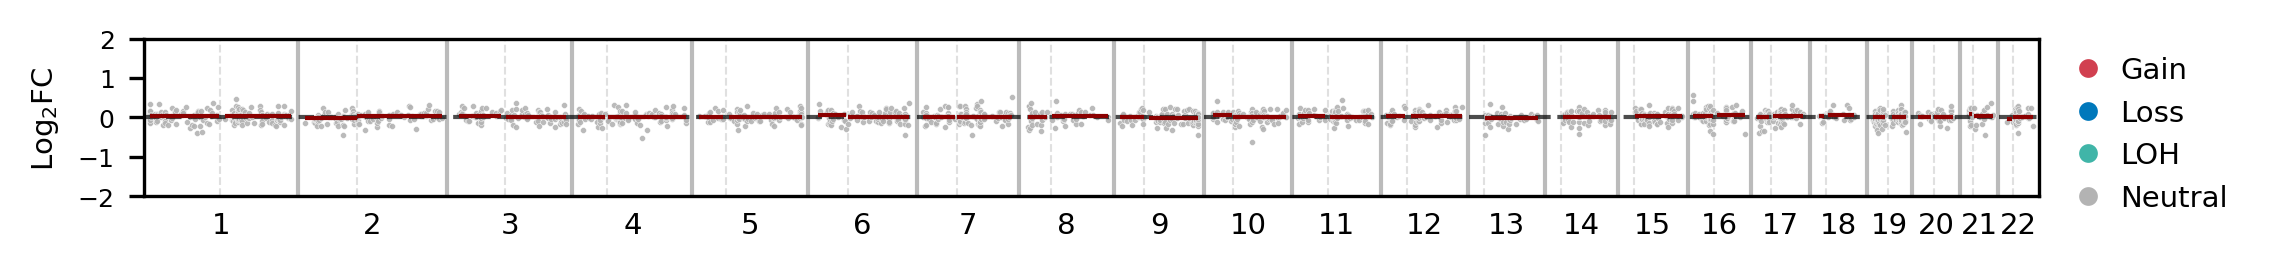

In [35]:
st_log2fc = st_log2fc_valid.loc[st_log2fc_valid['x'] == 'seed_N'].copy()
st_log2fc['gene_cna_type'] = 'Neutral'
fn = os.path.join(out_dir, gw_prefix + "rdr-cs-vs-seed.png")
plot_rdr(st_log2fc, out_fn = fn, figsize = (7, 1))

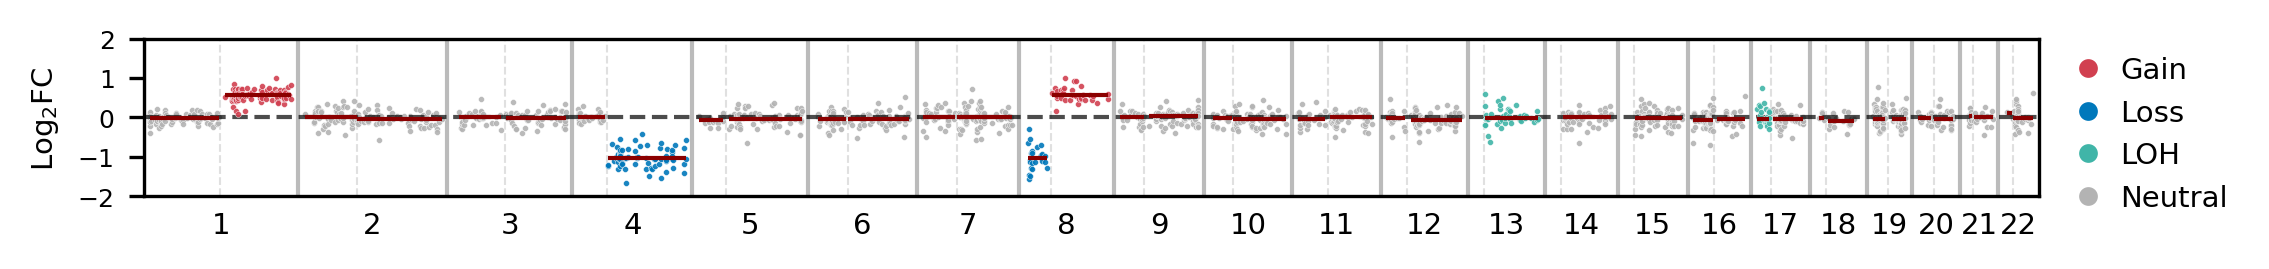

In [36]:
st_log2fc = st_log2fc_valid.loc[st_log2fc_valid['x'] == 'scCNASim-cs_N'].copy()
fn = os.path.join(out_dir, gw_prefix + "rdr-scCNASim-cs.png")
plot_rdr(st_log2fc, out_fn = fn, figsize = (7, 1))